# Интерпретация

In [8]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [9]:
data_path = r'C:\spbu_ml_2026\data\data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()
print(data.dtypes)


Размер датасета: (29905, 83)

Первые строки:
region_name_cat        str
district_cat         int64
corpus_cat           int64
developer_cat        int64
agreement_date         str
                    ...   
price_target       float64
hc_name_cat          int64
interior_cat       float64
class_cat            int64
stage_cat            int64
Length: 83, dtype: object


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

### ваш код
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('price_target')
cat_cols = data.select_dtypes(include=['object']).columns.tolist()


print("\nПроверка пропусков:")
print(data[num_cols + cat_cols].isnull().sum().sum(), "пропусков осталось")

X=data.drop('price_target', axis=1)
y=data['price_target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

preprocessor_raw = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', MinMaxScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])


models = {
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=1.0),
    'GradientBoosting': GradientBoostingRegressor(max_depth=5, random_state=42)
}
results = {}



Проверка пропусков:
23310 пропусков осталось


In [13]:
for name, model in models.items():
    pipeline_raw = Pipeline(steps=[('preprocessor', preprocessor_raw), ('regressor', model)])
    pipeline_raw.fit(X_train, y_train)
    y_pred_raw = pipeline_raw.predict(X_test)
    mse_raw = mean_squared_error(y_test, y_pred_raw)
    rmse_raw = np.sqrt(mse_raw)
    mape_raw = np.mean(np.abs((y_test - y_pred_raw) / np.maximum(np.abs(y_test), 1e-10))) * 100
    results[f'{name}_raw'] = {'MSE': mse_raw, 'RMSE': rmse_raw, 'MAPE': mape_raw}

    # С масштабированием
    pipeline_scaled = Pipeline(steps=[('preprocessor', preprocessor_scaled), ('regressor', model)])
    pipeline_scaled.fit(X_train, y_train)
    y_pred_scaled = pipeline_scaled.predict(X_test)
    mse_scaled = mean_squared_error(y_test, y_pred_scaled)
    rmse_scaled = np.sqrt(mse_scaled)
    mape_scaled = np.mean(np.abs((y_test - y_pred_scaled) / np.maximum(np.abs(y_test), 1e-10))) * 100
    results[f'{name}_scaled'] = {'MSE': mse_scaled, 'RMSE': rmse_scaled, 'MAPE': mape_scaled}
results_df = pd.DataFrame(results).T
print(results_df)

                                  MSE         RMSE       MAPE
LinearRegression_raw     1.906037e+07  4365.818750  10.066505
LinearRegression_scaled  1.906037e+07  4365.818750  10.066505
Lasso_raw                2.028749e+07  4504.163675  10.368963
Lasso_scaled             1.992772e+07  4464.047987  10.178470
GradientBoosting_raw     3.601505e+06  1897.763185   4.256166
GradientBoosting_scaled  3.579093e+06  1891.849201   4.280660


Получилось, что Линейная регрессия нечувствительна к нормализации данных, в то время, как Лассо и Бустинг имеют различия в метриках по сравнению с ненормализованными данными

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

Проверка пропусков ДО заполнения:
Числовые: 23310
Категориальные: 0

Проверка пропусков ПОСЛЕ заполнения:
Числовые: 23310
Категориальные: 0

Размер данных после обработки: (20933, 614)
Пропусков в обработанных данных: 0

Пропусков после масштабирования:
Raw: 0
StandardScaler: 0
MinMaxScaler: 0

РЕЗУЛЬТАТЫ (MAPE в %):
                                  MAPE
LinearRegression_raw             10.07
Lasso_raw                        10.37
GradientBoosting_raw              4.26
LinearRegression_StandardScaler  10.07
Lasso_StandardScaler             10.39
GradientBoosting_StandardScaler   4.27
LinearRegression_MinMaxScaler    10.07
Lasso_MinMaxScaler               10.18
GradientBoosting_MinMaxScaler     4.28


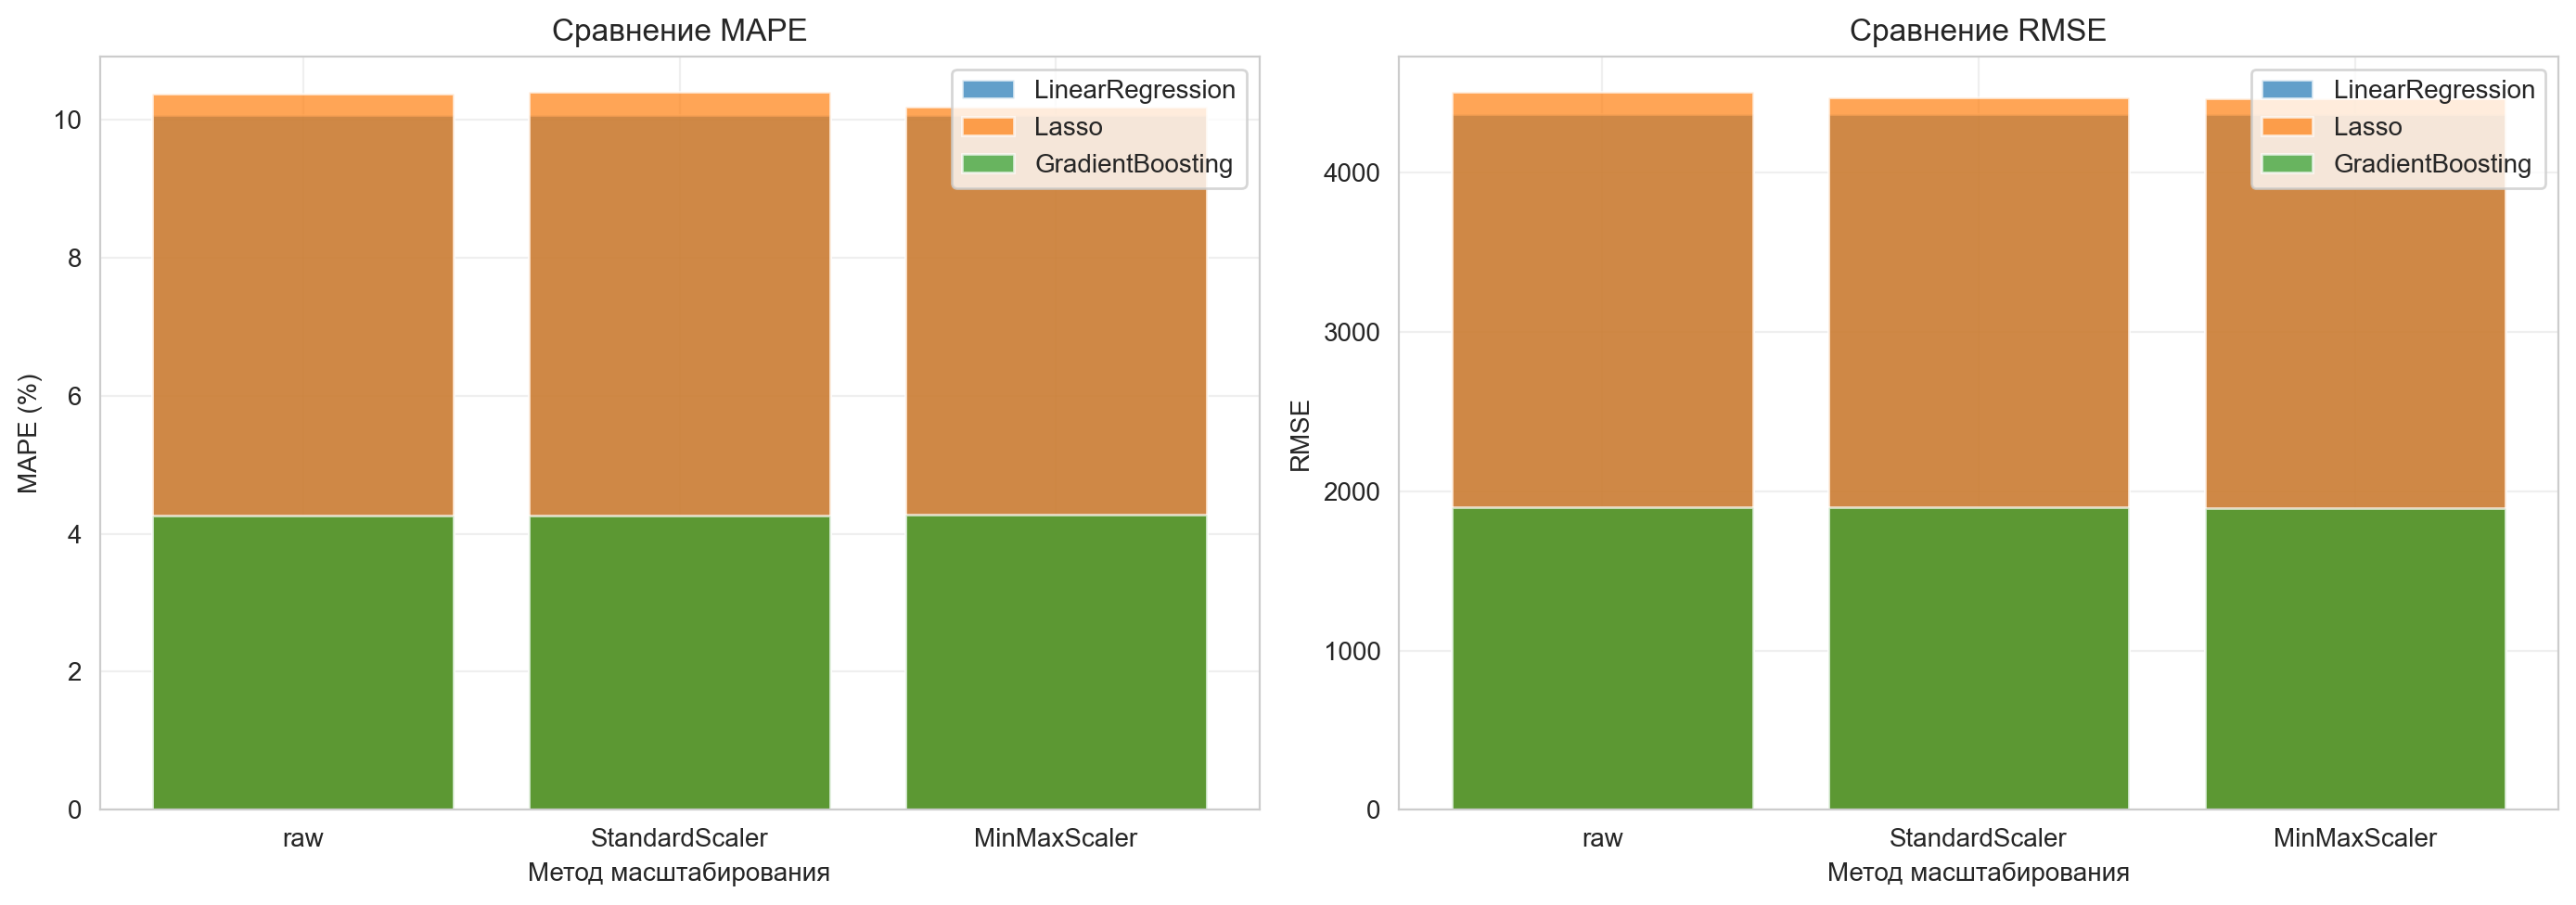


ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ LINEARREGRESSION:

Без масштабирования:
  location_mean_area_density: -2414707.4949
  location_hds_ratio_mean_mean: 50733.7622
  location_motel_cnt: 27751.0376
  location_highway_crossing_w_mean_distance: -24723.7652
  location_public_transport_platform_w_mean_distance: 24529.4333

StandardScaler:
  location_highway_crossing_w_mean_distance: -2307488.9367
  location_public_transport_platform_w_mean_distance: 2289351.1546
  location_std_levels_mean: -129063.2375
  location_shop_other_w_mean_distance: 127242.3734
  location_shop_product_w_mean_distance: 17876.1585

MinMaxScaler:
  location_highway_crossing_w_mean_distance: -24729003.7473
  location_public_transport_platform_w_mean_distance: 24533484.9167
  location_std_levels_mean: -1596843.9866
  location_shop_other_w_mean_distance: 1567230.8316
  location_shop_product_w_mean_distance: 191588.9062


In [14]:
### ваш код
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('price_target')
cat_cols = data.select_dtypes(include=['object']).columns.tolist()

print("Проверка пропусков ДО заполнения:")
print(f"Числовые: {data[num_cols].isnull().sum().sum()}")
print(f"Категориальные: {data[cat_cols].isnull().sum().sum() if cat_cols else 0}")

for col in num_cols:
    if data[col].isnull().any():
        median_val = data[col].median()
        if pd.isna(median_val):
            median_val = 0
        data[col].fillna(median_val, inplace=True)

for col in cat_cols:
    if data[col].isnull().any():
        mode_val = data[col].mode()
        if not mode_val.empty:
            data[col].fillna(mode_val[0], inplace=True)
        else:
            data[col].fillna("Unknown", inplace=True)

print("\nПроверка пропусков ПОСЛЕ заполнения:")
print(f"Числовые: {data[num_cols].isnull().sum().sum()}")
print(f"Категориальные: {data[cat_cols].isnull().sum().sum() if cat_cols else 0}")

X = data.drop('price_target', axis=1)
y = data['price_target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_num = imputer_num.fit_transform(X_train[num_cols])
X_test_num = imputer_num.transform(X_test[num_cols])

if cat_cols:
    X_train_cat_raw = imputer_cat.fit_transform(X_train[cat_cols])
    X_test_cat_raw = imputer_cat.transform(X_test[cat_cols])
    X_train_cat = encoder.fit_transform(X_train_cat_raw)
    X_test_cat = encoder.transform(X_test_cat_raw)
    X_train_processed = np.hstack([X_train_num, X_train_cat])
    X_test_processed = np.hstack([X_test_num, X_test_cat])
    cat_feature_names = encoder.get_feature_names_out(cat_cols).tolist()
else:
    X_train_processed = X_train_num
    X_test_processed = X_test_num
    cat_feature_names = []

feature_names = num_cols + cat_feature_names

print(f"\nРазмер данных после обработки: {X_train_processed.shape}")
print(f"Пропусков в обработанных данных: {np.isnan(X_train_processed).sum()}")

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train_processed)
X_test_std = scaler_std.transform(X_test_processed)

X_train_minmax = scaler_minmax.fit_transform(X_train_processed)
X_test_minmax = scaler_minmax.transform(X_test_processed)

X_train_raw = X_train_processed
X_test_raw = X_test_processed

print(f"\nПропусков после масштабирования:")
print(f"Raw: {np.isnan(X_train_raw).sum()}")
print(f"StandardScaler: {np.isnan(X_train_std).sum()}")
print(f"MinMaxScaler: {np.isnan(X_train_minmax).sum()}")

models = {
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=1.0, max_iter=10000),
    'GradientBoosting': GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100)
}

scaled_versions = {
    'raw': (X_train_raw, X_test_raw),
    'StandardScaler': (X_train_std, X_test_std),
    'MinMaxScaler': (X_train_minmax, X_test_minmax)
}

results = {}

for scaler_name, (X_tr, X_te) in scaled_versions.items():
    for model_name, model in models.items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((y_test - y_pred) / np.maximum(np.abs(y_test), 1e-10))) * 100

        results[f'{model_name}_{scaler_name}'] = {'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ (MAPE в %):")
print("="*60)
print(results_df[['MAPE']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name in models.keys():
    mape_values = [results[f'{model_name}_{s}']['MAPE'] for s in scaled_versions.keys()]
    axes[0].bar(list(scaled_versions.keys()), mape_values, alpha=0.7, label=model_name)

    rmse_values = [results[f'{model_name}_{s}']['RMSE'] for s in scaled_versions.keys()]
    axes[1].bar(list(scaled_versions.keys()), rmse_values, alpha=0.7, label=model_name)

axes[0].set_xlabel('Метод масштабирования')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('Сравнение MAPE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Метод масштабирования')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Сравнение RMSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ LINEARREGRESSION:")
print("="*60)

for scaler_name, (X_tr, X_te) in scaled_versions.items():
    lr = LinearRegression()
    lr.fit(X_tr, y_train)
    coef = lr.coef_

    print(f"\n{scaler_name if scaler_name != 'raw' else 'Без масштабирования'}:")
    coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
    coef_df['abs_coef'] = np.abs(coef_df['coef'])
    top5 = coef_df.nlargest(5, 'abs_coef')
    for _, row in top5.iterrows():
        print(f"  {row['feature']}: {row['coef']:.4f}")

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

LinearRegression R²: 0.8064
GradientBoosting R²: 0.9637

Анализ признака: square
Тип: continuous


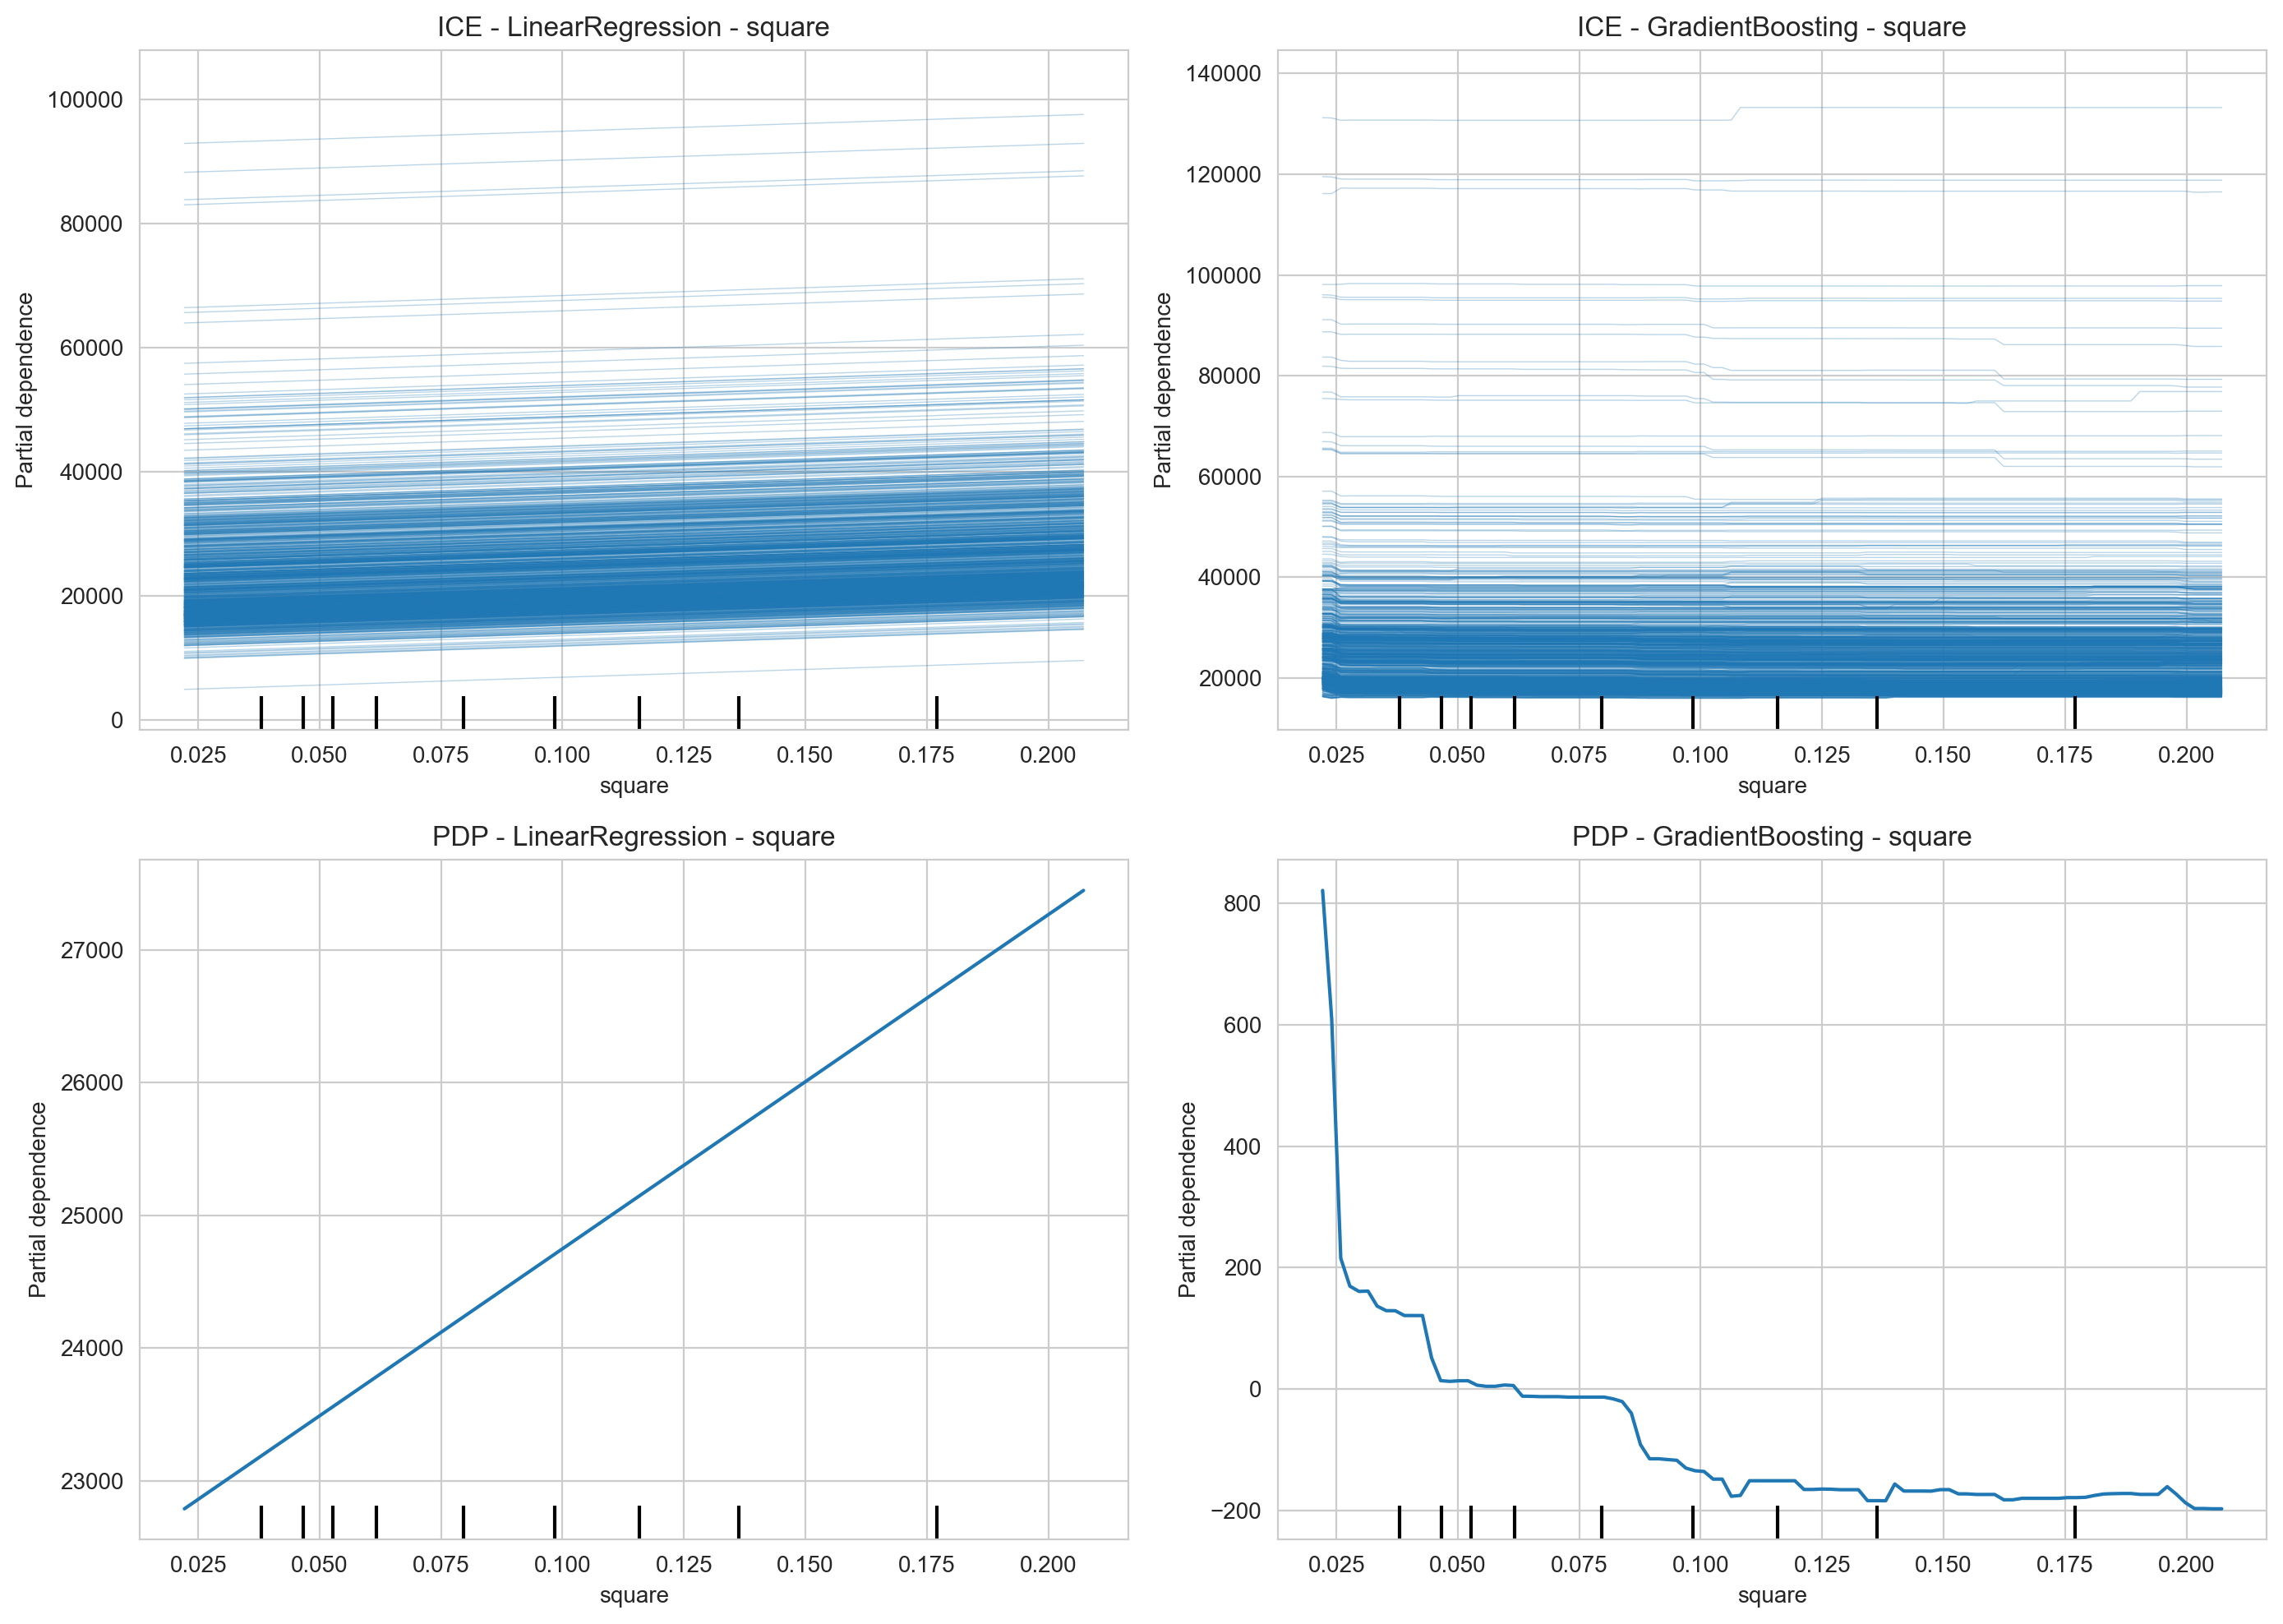


ЭКСПЕРИМЕНТ С ВЫБРОСАМИ
Оригинальный диапазон square: [0.000, 1.000]

Выброс square = -0.5 (вне диапазона [0.000, 1.000]):
  LinearRegression - среднее предсказание: 9591.41
  GradientBoosting - среднее предсказание: 25750.41

Выброс square = -0.3 (вне диапазона [0.000, 1.000]):
  LinearRegression - среднее предсказание: 14626.69
  GradientBoosting - среднее предсказание: 25750.41

Выброс square = 1.3 (вне диапазона [0.000, 1.000]):
  LinearRegression - среднее предсказание: 54908.88
  GradientBoosting - среднее предсказание: 27366.23

Выброс square = 1.5 (вне диапазона [0.000, 1.000]):
  LinearRegression - среднее предсказание: 59944.16
  GradientBoosting - среднее предсказание: 27366.23

Выброс square = 2.0 (вне диапазона [0.000, 1.000]):
  LinearRegression - среднее предсказание: 72532.34
  GradientBoosting - среднее предсказание: 27366.23


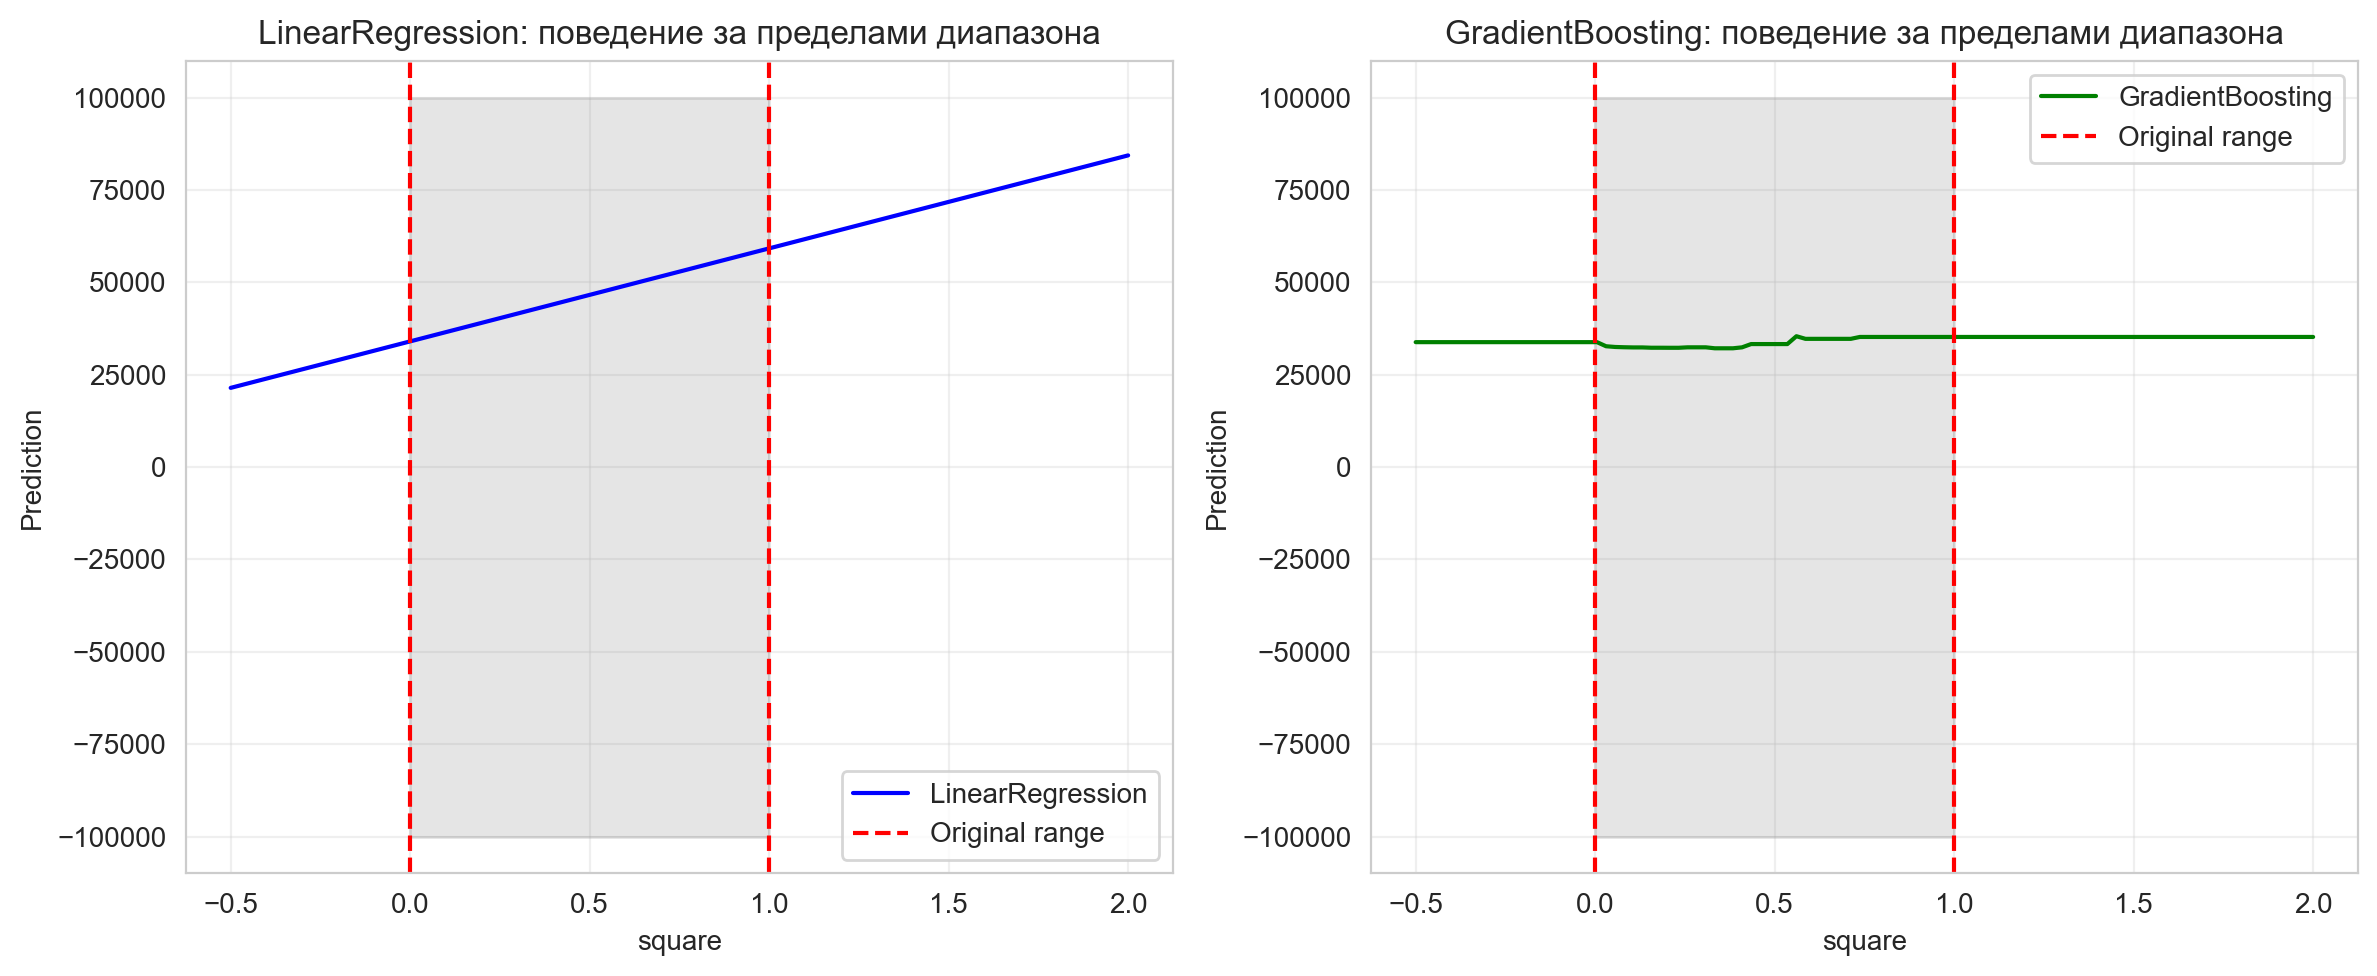

In [15]:
feature_to_analyze = 'square'

if feature_to_analyze in cat_cols:
    feature_idx = cat_cols.index(feature_to_analyze)
    feature_type = 'categorical'
else:
    feature_idx = num_cols.index(feature_to_analyze)
    feature_type = 'continuous'

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if cat_cols:
    encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    cat_features = encoder.get_feature_names_out(cat_cols).tolist()
else:
    cat_features = []
feature_names = num_cols + cat_features
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

lr = LinearRegression()
lr.fit(X_train_df, y_train)

gb = GradientBoostingRegressor(max_depth=5, random_state=42)
gb.fit(X_train_df, y_train)

print(f"LinearRegression R²: {lr.score(X_test_df, y_test):.4f}")
print(f"GradientBoosting R²: {gb.score(X_test_df, y_test):.4f}")

print("\nАнализ признака:", feature_to_analyze)
print("Тип:", feature_type)

if feature_type == 'continuous':
    feature_idx_in_df = feature_names.index(feature_to_analyze)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    PartialDependenceDisplay.from_estimator(lr, X_train_df, [feature_idx_in_df],
                                            kind='individual', ax=axes[0, 0])
    axes[0, 0].set_title(f'ICE - LinearRegression - {feature_to_analyze}')

    PartialDependenceDisplay.from_estimator(gb, X_train_df, [feature_idx_in_df],
                                            kind='individual', ax=axes[0, 1])
    axes[0, 1].set_title(f'ICE - GradientBoosting - {feature_to_analyze}')

    PartialDependenceDisplay.from_estimator(lr, X_train_df, [feature_idx_in_df],
                                            kind='average', ax=axes[1, 0])
    axes[1, 0].set_title(f'PDP - LinearRegression - {feature_to_analyze}')

    PartialDependenceDisplay.from_estimator(gb, X_train_df, [feature_idx_in_df],
                                            kind='average', ax=axes[1, 1])
    axes[1, 1].set_title(f'PDP - GradientBoosting - {feature_to_analyze}')

    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ С ВЫБРОСАМИ")
print("="*60)

if feature_type == 'continuous':
    original_min = X_train_df[feature_to_analyze].min()
    original_max = X_train_df[feature_to_analyze].max()
    print(f"Оригинальный диапазон {feature_to_analyze}: [{original_min:.3f}, {original_max:.3f}]")

    X_test_outliers = X_test_df.copy()
    outlier_values = [-0.5, -0.3, 1.3, 1.5, 2.0]

    for outlier_val in outlier_values:
        X_test_outliers[feature_to_analyze] = outlier_val
        X_test_outliers_single = X_test_df.copy()
        X_test_outliers_single[feature_to_analyze] = outlier_val

        lr_pred = lr.predict(X_test_outliers_single)
        gb_pred = gb.predict(X_test_outliers_single)

        print(f"\nВыброс {feature_to_analyze} = {outlier_val} (вне диапазона [{original_min:.3f}, {original_max:.3f}]):")
        print(f"  LinearRegression - среднее предсказание: {lr_pred.mean():.2f}")
        print(f"  GradientBoosting - среднее предсказание: {gb_pred.mean():.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    x_range = np.linspace(-0.5, 2.0, 100).reshape(-1, 1)
    X_temp = X_test_df.iloc[0:1].copy()

    lr_preds = []
    gb_preds = []
    for val in x_range.flatten():
        X_temp[feature_to_analyze] = val
        lr_preds.append(lr.predict(X_temp)[0])
        gb_preds.append(gb.predict(X_temp)[0])

    axes[0].plot(x_range, lr_preds, 'b-', label='LinearRegression')
    axes[0].axvline(x=original_min, color='red', linestyle='--', label='Original range')
    axes[0].axvline(x=original_max, color='red', linestyle='--')
    axes[0].fill_between([original_min, original_max], -100000, 100000, alpha=0.2, color='gray')
    axes[0].set_xlabel(feature_to_analyze)
    axes[0].set_ylabel('Prediction')
    axes[0].set_title('LinearRegression: поведение за пределами диапазона')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x_range, gb_preds, 'g-', label='GradientBoosting')
    axes[1].axvline(x=original_min, color='red', linestyle='--', label='Original range')
    axes[1].axvline(x=original_max, color='red', linestyle='--')
    axes[1].fill_between([original_min, original_max], -100000, 100000, alpha=0.2, color='gray')
    axes[1].set_xlabel(feature_to_analyze)
    axes[1].set_ylabel('Prediction')
    axes[1].set_title('GradientBoosting: поведение за пределами диапазона')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

LinearRegression R²: 0.8064
GradientBoosting R²: 0.9637

Анализируемый признак: location_amenity_restaurant_w_mean_distance
Базовое значение (медиана по обучающей выборке): 0.87
Базовое значение в масштабированном виде: 0.9994


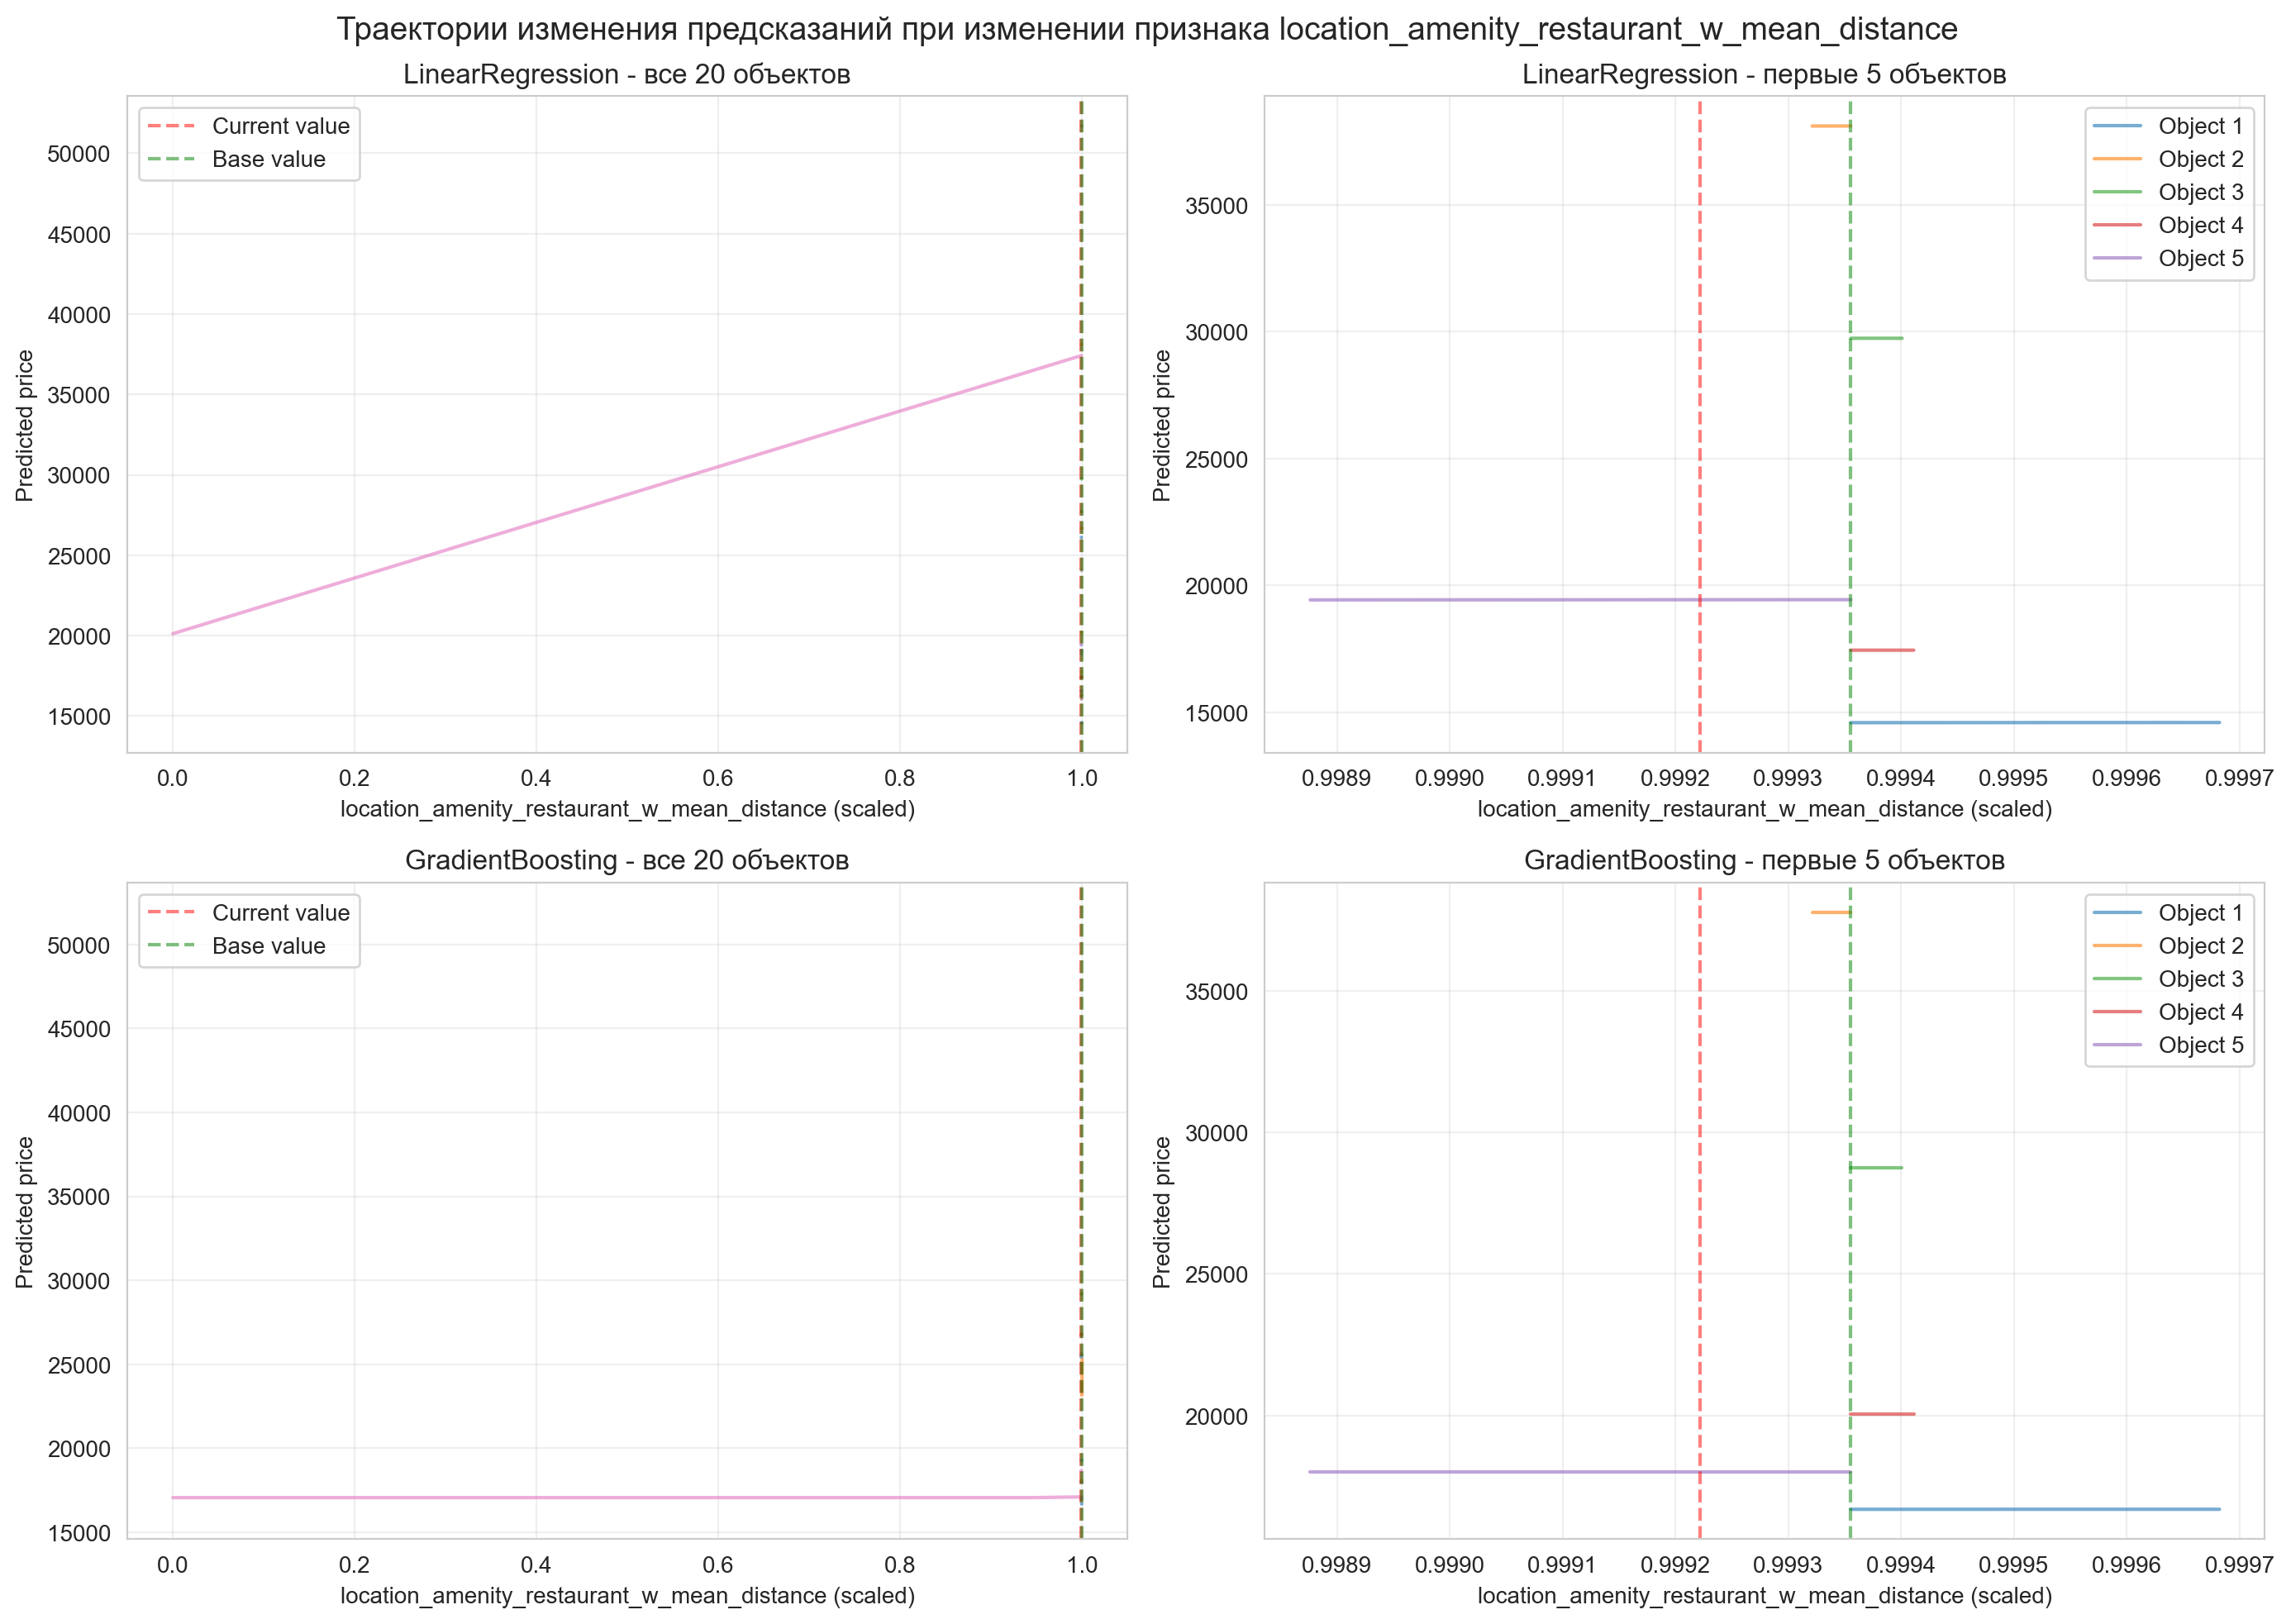


Детальный анализ объекта 2455:
  Истинная цена: 17370.23

LinearRegression:
  Предсказание при текущем значении location_amenity_restaurant_w_mean_distance: 14596.70
  Предсказание при базовом значении (медиана): 14591.04
  Разница: -5.65

GradientBoosting:
  Предсказание при текущем значении location_amenity_restaurant_w_mean_distance: 16690.75
  Предсказание при базовом значении (медиана): 16690.75
  Разница: 0.00


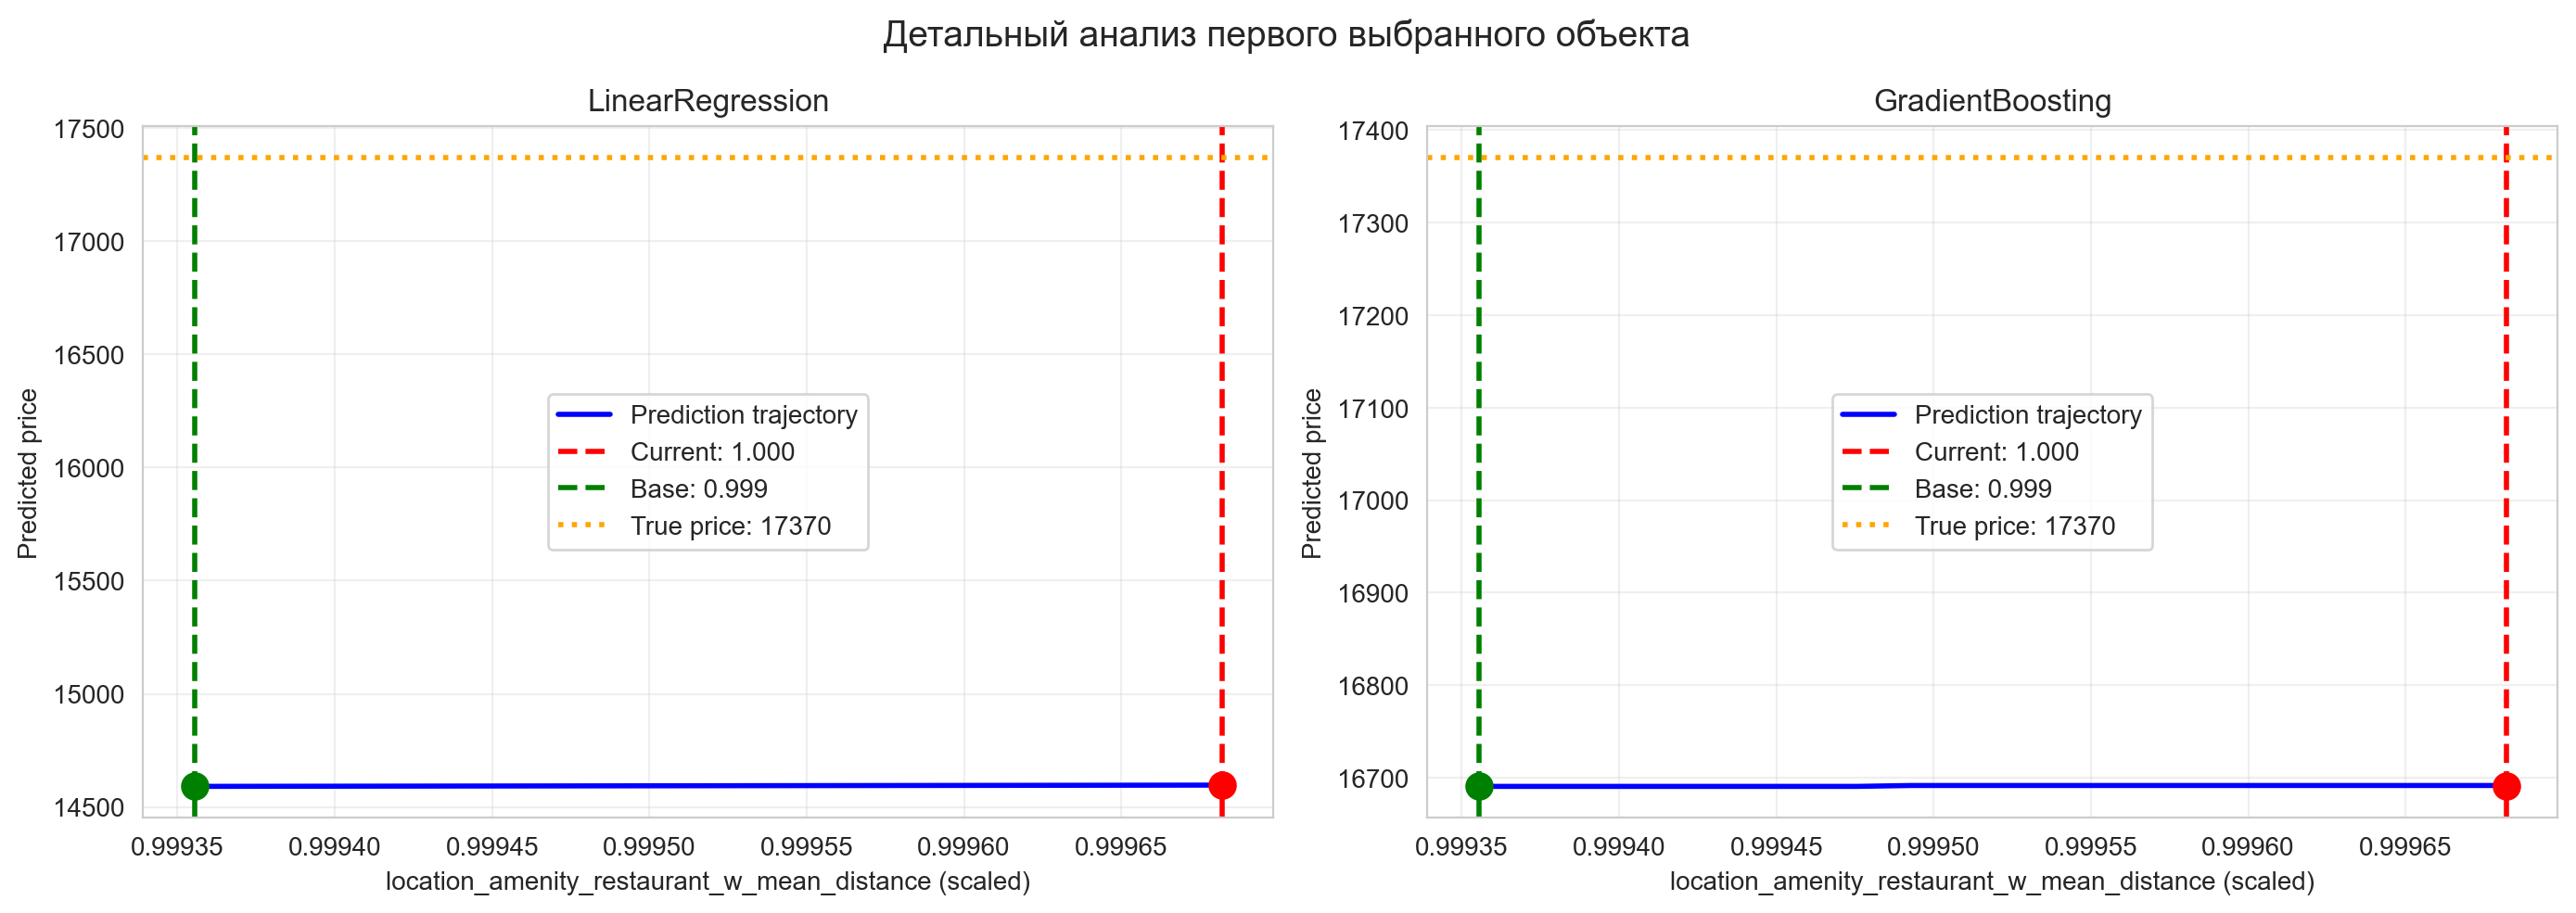


СТАТИСТИКА ПО ВСЕМ 20 ОБЪЕКТАМ

LinearRegression:
  Среднее изменение: 865.50
  Медиана изменения: -0.17
  Стандартное отклонение: 3769.05
  Минимальное изменение: -11.16
  Максимальное изменение: 17294.41

GradientBoosting:
  Среднее изменение: -95.23
  Медиана изменения: 0.00
  Стандартное отклонение: 465.35
  Минимальное изменение: -2121.90
  Максимальное изменение: 51.45


In [21]:
### ваш код
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = MinMaxScaler()

X_train_num = imputer_num.fit_transform(X_train[num_cols])
X_test_num = imputer_num.transform(X_test[num_cols])

if cat_cols:
    X_train_cat_raw = imputer_cat.fit_transform(X_train[cat_cols])
    X_test_cat_raw = imputer_cat.transform(X_test[cat_cols])
    X_train_cat = encoder.fit_transform(X_train_cat_raw)
    X_test_cat = encoder.transform(X_test_cat_raw)
    X_train_processed = np.hstack([X_train_num, X_train_cat])
    X_test_processed = np.hstack([X_test_num, X_test_cat])
    cat_feature_names = encoder.get_feature_names_out(cat_cols).tolist()
else:
    X_train_processed = X_train_num
    X_test_processed = X_test_num
    cat_feature_names = []

feature_names = num_cols + cat_feature_names

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

gb = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100)
gb.fit(X_train_scaled, y_train)

print(f"LinearRegression R²: {lr.score(X_test_scaled, y_test):.4f}")
print(f"GradientBoosting R²: {gb.score(X_test_scaled, y_test):.4f}")

feature_to_analyze = 'location_amenity_restaurant_w_mean_distance'
feature_idx = num_cols.index(feature_to_analyze)
base_value = X_train[feature_to_analyze].median()

print(f"\nАнализируемый признак: {feature_to_analyze}")
print(f"Базовое значение (медиана по обучающей выборке): {base_value:.2f}")

n_objects = 20
n_steps = 20

np.random.seed(42)
indices = np.random.choice(len(X_test_scaled), n_objects, replace=False)

def get_base_vector_scaled(feature_idx, base_value, scaler, num_cols, cat_feature_names, X_train_processed):
    base_vector = X_train_processed[0:1].copy()
    base_vector[0, feature_idx] = base_value
    base_vector_scaled = scaler.transform(base_vector)
    return base_vector_scaled[0, feature_idx]

def get_scaled_value(feature_idx, value, scaler, X_train_processed):
    temp_vector = X_train_processed[0:1].copy()
    temp_vector[0, feature_idx] = value
    temp_scaled = scaler.transform(temp_vector)
    return temp_scaled[0, feature_idx]

base_value_scaled = get_scaled_value(feature_idx, base_value, scaler, X_train_processed)

print(f"Базовое значение в масштабированном виде: {base_value_scaled:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Траектории изменения предсказаний при изменении признака {feature_to_analyze}', fontsize=14)

models_to_plot = [('LinearRegression', lr), ('GradientBoosting', gb)]

for idx, (model_name, model) in enumerate(models_to_plot):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]

    for i, test_idx in enumerate(indices):
        instance = X_test_scaled[test_idx].copy()
        current_val = instance[feature_idx]

        trajectory_preds = []
        trajectory_values = []
        values = np.linspace(current_val, base_value_scaled, n_steps)

        for val in values:
            instance[feature_idx] = val
            pred = model.predict(instance.reshape(1, -1))[0]
            trajectory_preds.append(pred)
            trajectory_values.append(val)

        ax1.plot(trajectory_values, trajectory_preds, alpha=0.6, linewidth=1.5)

        if i < 5:
            ax2.plot(trajectory_values, trajectory_preds, alpha=0.6, linewidth=1.5, label=f'Object {i+1}')

    ax1.axvline(x=current_val, color='red', linestyle='--', alpha=0.5, label='Current value')
    ax1.axvline(x=base_value_scaled, color='green', linestyle='--', alpha=0.5, label='Base value')
    ax1.set_xlabel(f'{feature_to_analyze} (scaled)')
    ax1.set_ylabel('Predicted price')
    ax1.set_title(f'{model_name} - все {n_objects} объектов')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.axvline(x=current_val, color='red', linestyle='--', alpha=0.5)
    ax2.axvline(x=base_value_scaled, color='green', linestyle='--', alpha=0.5)
    ax2.set_xlabel(f'{feature_to_analyze} (scaled)')
    ax2.set_ylabel('Predicted price')
    ax2.set_title(f'{model_name} - первые 5 объектов')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Детальный анализ первого выбранного объекта', fontsize=14)

test_idx = indices[0]
instance = X_test_scaled[test_idx].copy()
current_val = instance[feature_idx]

print(f"\nДетальный анализ объекта {test_idx}:")
print(f"  Истинная цена: {y_test.iloc[test_idx]:.2f}")

for idx, (model_name, model) in enumerate(models_to_plot):
    values = np.linspace(current_val, base_value_scaled, n_steps)
    trajectory = []

    for val in values:
        instance_copy = instance.copy()
        instance_copy[feature_idx] = val
        pred = model.predict(instance_copy.reshape(1, -1))[0]
        trajectory.append(pred)

    axes[idx].plot(values, trajectory, 'b-', linewidth=2, label='Prediction trajectory')
    axes[idx].axvline(x=current_val, color='red', linestyle='--', linewidth=2, label=f'Current: {current_val:.3f}')
    axes[idx].axvline(x=base_value_scaled, color='green', linestyle='--', linewidth=2, label=f'Base: {base_value_scaled:.3f}')
    axes[idx].axhline(y=y_test.iloc[test_idx], color='orange', linestyle=':', linewidth=2, label=f'True price: {y_test.iloc[test_idx]:.0f}')

    pred_at_current = model.predict(instance.reshape(1, -1))[0]
    instance[feature_idx] = base_value_scaled
    pred_at_base = model.predict(instance.reshape(1, -1))[0]

    axes[idx].scatter(current_val, pred_at_current, color='red', s=100, zorder=5)
    axes[idx].scatter(base_value_scaled, pred_at_base, color='green', s=100, zorder=5)

    axes[idx].set_xlabel(f'{feature_to_analyze} (scaled)')
    axes[idx].set_ylabel('Predicted price')
    axes[idx].set_title(f'{model_name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

    print(f"\n{model_name}:")
    print(f"  Предсказание при текущем значении {feature_to_analyze}: {pred_at_current:.2f}")
    print(f"  Предсказание при базовом значении (медиана): {pred_at_base:.2f}")
    print(f"  Разница: {pred_at_base - pred_at_current:.2f}")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("СТАТИСТИКА ПО ВСЕМ 20 ОБЪЕКТАМ")
print("="*60)

all_changes_lr = []
all_changes_gb = []

for test_idx in indices:
    instance = X_test_scaled[test_idx].copy()
    pred_current_lr = lr.predict(instance.reshape(1, -1))[0]

    instance[feature_idx] = base_value_scaled
    pred_base_lr = lr.predict(instance.reshape(1, -1))[0]
    all_changes_lr.append(pred_base_lr - pred_current_lr)

    instance = X_test_scaled[test_idx].copy()
    pred_current_gb = gb.predict(instance.reshape(1, -1))[0]

    instance[feature_idx] = base_value_scaled
    pred_base_gb = gb.predict(instance.reshape(1, -1))[0]
    all_changes_gb.append(pred_base_gb - pred_current_gb)

print(f"\nLinearRegression:")
print(f"  Среднее изменение: {np.mean(all_changes_lr):.2f}")
print(f"  Медиана изменения: {np.median(all_changes_lr):.2f}")
print(f"  Стандартное отклонение: {np.std(all_changes_lr):.2f}")
print(f"  Минимальное изменение: {np.min(all_changes_lr):.2f}")
print(f"  Максимальное изменение: {np.max(all_changes_lr):.2f}")

print(f"\nGradientBoosting:")
print(f"  Среднее изменение: {np.mean(all_changes_gb):.2f}")
print(f"  Медиана изменения: {np.median(all_changes_gb):.2f}")
print(f"  Стандартное отклонение: {np.std(all_changes_gb):.2f}")
print(f"  Минимальное изменение: {np.min(all_changes_gb):.2f}")
print(f"  Максимальное изменение: {np.max(all_changes_gb):.2f}")

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

In [ ]:
### ваш код

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



In [2]:
### ваш код

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 
